# Hurdle-distribution primer: canonical curve → probabilities

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/hurdle_fit_primer.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/hurdle_fit_primer.ipynb)

Flood depth is zero most of the time and continuous only in the upper tail.
**crc-sdk** encodes that as a *hurdle distribution* — a point mass at zero depth
plus a truncated parametric family above it — and persists the fitted parameters
in canonical Parquet.

This short notebook uses the checked-in Cologne OS-Climate fixture so it runs
offline. It focuses on the fitted result rather than repeating ingestion:

1. **Inspect** the canonical hazard row and its persisted parameters.
2. **Reconstruct** the `HurdleDistribution` from Parquet.
3. **Evaluate and sample** the distribution across useful return periods.

The fixture was produced by the original live SDK smoke test from WRI Aqueduct
riverine flood depth (historical, 1980).


**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-screen-mortgage-flood/SKILL.md) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)


## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages and downloads any small repository files used by the analysis.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry]==0.7.1', 'crc-framework==0.2.5', 'duckdb>=1.4.5,<2', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "duckdb", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {'fixtures/os_climate/hazard.parquet': '60550f032692da9a824ff3a832dd142d4732717ff2a7e6084781d803c73a6c96'}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

from crc_sdk import HurdleDistribution
from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.types import CurveParameters

# Use the native interactive renderer; maintainers can opt into saved PNG previews.
STATIC_PREVIEW = os.environ.get("CRC_NOTEBOOK_STATIC_PREVIEW") == "1"
pio.renderers.default = (
    "colab" if IN_COLAB else "plotly_mimetype+png" if STATIC_PREVIEW else "plotly_mimetype"
)

HAZARD_PATH = Path("../fixtures/os_climate/hazard.parquet")
RETURN_PERIODS = np.asarray([2, 5, 10, 25, 50, 100, 250, 500, 1000], dtype=float)
SAMPLES = 10_000
SEED = 42


## 1. Inspect the canonical hazard fixture

The fixture preserves the complete canonical schema and Parquet metadata from
the live ingest. Several H3 cells overlap the same source pixel; one row is
enough to inspect the shared fitted curve.


In [3]:
hazard = read_hazard_dataset(HAZARD_PATH)
print(f"{hazard.num_rows} canonical rows <- {HAZARD_PATH}")
hazard.to_pandas()[
    [
        "cell_index",
        "pathway",
        "horizon",
        "curve_kind",
        "curve_type",
        "curve_location",
        "curve_scale",
        "curve_atom_probability",
    ]
].head()


11 canonical rows <- ../fixtures/os_climate/hazard.parquet


,cell_index,pathway,horizon,curve_kind,curve_type,curve_location,curve_scale,curve_atom_probability
0,617549611774771199,historical,1980,hurdle,gumbel_r,-7.906087,0.435064,0.5
1,617549611775295487,historical,1980,hurdle,gumbel_r,-7.906087,0.435064,0.5
2,617549611775557631,historical,1980,hurdle,gumbel_r,-7.906087,0.435064,0.5
3,617549611776344063,historical,1980,hurdle,gumbel_r,-7.906087,0.435064,0.5
4,617549611779227647,historical,1980,hurdle,gumbel_r,-7.906087,0.435064,0.5


## 2. Reconstruct the fitted hurdle

`CurveParameters.to_distribution()` validates the persisted fields and rebuilds
the same framework `HurdleDistribution` that the ingest fitted. The atom models
dry events; the Gumbel tail models positive flood depth.


In [4]:
row = hazard.slice(0, 1).to_pylist()[0]
fitted = CurveParameters.model_validate(
    {
        key: row[key]
        for key in (
            "curve_kind",
            "curve_type",
            "curve_shape",
            "curve_location",
            "curve_scale",
            "curve_atom_probability",
            "curve_atom_location",
        )
    }
).to_distribution()
assert isinstance(fitted, HurdleDistribution)
print(
    "hurdle: "
    f"atom={fitted.atom_probability}@{fitted.atom_location}, "
    f"{fitted.base.family}(location={fitted.base.location:.4f}, "
    f"scale={fitted.base.scale:.4f}, shape={fitted.base.shape})"
)


hurdle: atom=0.5@0.0, gumbel_r(location=-7.9061, scale=0.4351, shape=None)


## 3. Evaluate return levels and sampling error

The exact PPF gives deterministic return-period depth. Empirical quantiles from
10,000 samples should converge toward it; their residuals quantify Monte Carlo
noise rather than fitting error.


In [5]:
probabilities = 1.0 - 1.0 / RETURN_PERIODS
exact = fitted.quantiles(probabilities)
samples = fitted.sample(SAMPLES, seed=SEED)
sampled = np.quantile(samples, probabilities)
compare = pd.DataFrame(
    {
        "return_period": RETURN_PERIODS,
        "probability": probabilities,
        "exact_ppf": exact,
        "sampled_quantile": sampled,
        "sampling_residual": sampled - exact,
    }
)
print(
    "sample-vs-curve: "
    f"mae={np.mean(np.abs(compare['sampling_residual'])):.4f}, "
    f"rmse={np.sqrt(np.mean(np.square(compare['sampling_residual']))):.4f}"
)
print(
    "sample atom probability: "
    f"configured={fitted.atom_probability:.4f}, "
    f"empirical={np.mean(samples == fitted.atom_location):.4f}"
)
compare


sample-vs-curve: mae=0.0457, rmse=0.0673
sample atom probability: configured=0.5000, empirical=0.4972


,return_period,probability,exact_ppf,sampled_quantile,sampling_residual
0,2.0,0.500,0.000000,0.002437,0.002437
1,5.0,0.800,0.398645,0.397724,-0.000921
2,10.0,0.900,0.700209,0.703064,0.002855
3,25.0,0.960,1.098854,1.082689,-0.016165
4,50.0,0.980,1.400417,1.361589,-0.038828
5,100.0,0.990,1.701981,1.720299,0.018318
6,250.0,0.996,2.100626,2.022947,-0.077679
7,500.0,0.998,2.402189,2.289319,-0.112870
8,1000.0,0.999,2.703752,2.562691,-0.141061


## 4. Visualize


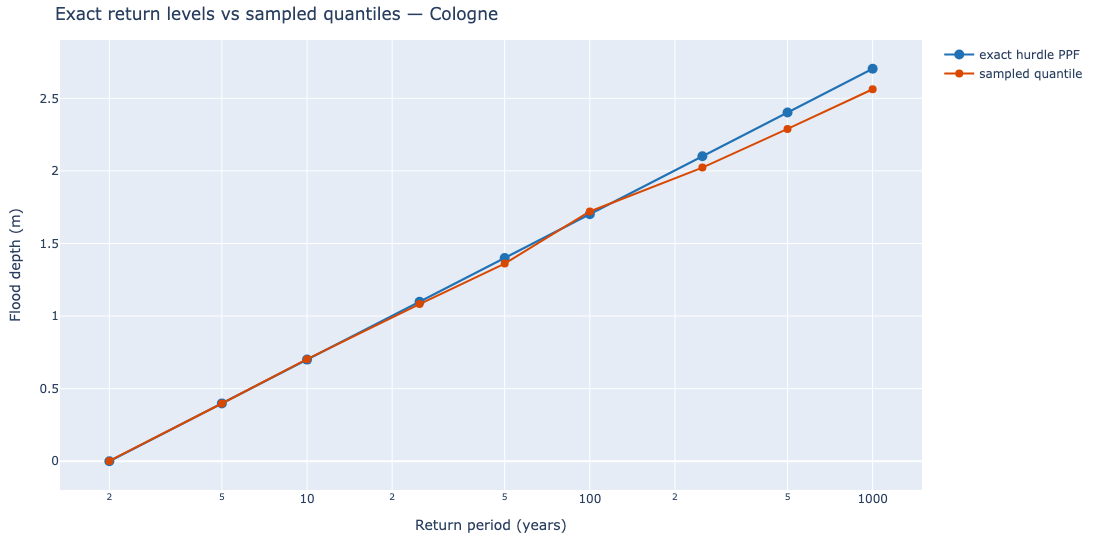

In [6]:
fig_fit = go.Figure()
fig_fit.add_trace(
    go.Scatter(
        x=compare["return_period"],
        y=compare["exact_ppf"],
        mode="markers+lines",
        name="exact hurdle PPF",
        marker=dict(size=10, color="#2171B5"),
    )
)
fig_fit.add_trace(
    go.Scatter(
        x=compare["return_period"],
        y=compare["sampled_quantile"],
        mode="markers+lines",
        name="sampled quantile",
        marker=dict(size=8, color="#D94801"),
    )
)
fig_fit.update_layout(
    title="Exact return levels vs sampled quantiles — Cologne",
    xaxis_title="Return period (years)",
    yaxis_title="Flood depth (m)",
    xaxis_type="log",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_fit.show()


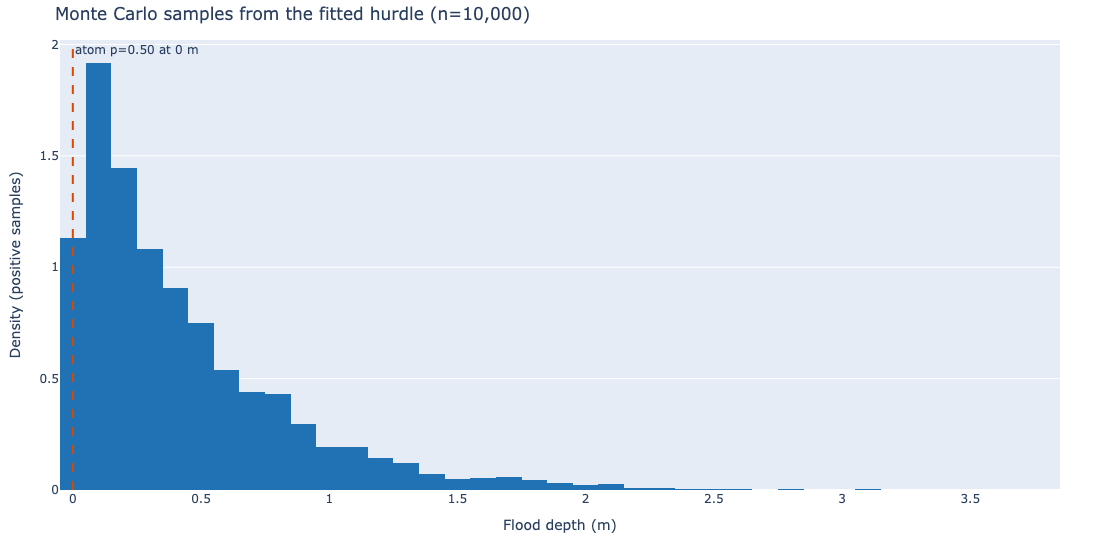

In [7]:
positive = samples[samples > fitted.atom_location]
fig_hist = go.Figure()
fig_hist.add_trace(
    go.Histogram(
        x=positive,
        nbinsx=40,
        name="tail samples",
        marker_color="#2171B5",
        histnorm="probability density",
    )
)
fig_hist.add_vline(
    x=fitted.atom_location,
    line_dash="dash",
    line_color="#D94801",
    annotation_text=f"atom p={fitted.atom_probability:.2f} at 0 m",
)
fig_hist.update_layout(
    title=f"Monte Carlo samples from the fitted hurdle (n={SAMPLES:,})",
    xaxis_title="Flood depth (m)",
    yaxis_title="Density (positive samples)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_hist.show()


## Where this shows up next

- [`asset_portfolio_evaluation.ipynb`](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/asset_portfolio_evaluation.ipynb) reuses the
  same canonical file to evaluate a small warehouse portfolio.
- [`flood_risk_by_province.ipynb`](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/flood_risk_by_province.ipynb) uses the current curated JRC
  canonicalization policy over an area, then joins to admin boundaries.
